# Visualization of Pettitt-Based Melt Detection Using Representative Pixels per Cluster

This code visualizes Pettitt-test-derived melt onset date (MOD) and melt end date (MED) overlaid on the ∆Tb time series of representative pixels for each cluster, in order to illustrate the behavior of the Pettitt-test-based detection framework.

Representative pixels were selected by minimizing the root mean square error (RMSE) between the pixel-level 35-year ∆Tb climatology and the corresponding cluster-mean climatology. This ensures that the selected pixel best captures the characteristic seasonal signal of each cluster.

For each representative pixel, the year with the lowest RMSE relative to the climatology was further selected for visualization, providing a clean and representative example of melt dynamics.

The resulting plots include:
- The ∆Tb time series
- Pettitt change point
- Derived MOD and MED
- Winter baseline (mean − standard deviation)
- Summer baseline (mean + standard deviation)

These visualizations help demonstrate how the Pettitt test identifies abrupt transitions in ∆Tb and how these transitions relate to physically meaningful melt metrics across clusters.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Define Functions for Selecting Representative Pixels and Years for Pettitt-Based Melt Detection Visualization

To illustrate the Pettitt-test-based detection of melt onset (MOD) and melt end (MED), representative pixels were selected for each cluster, ensuring that in situ observations can be directly compared within the visualization.

First, candidate pixels were restricted to locations where in situ MOD was available for at least one year, enabling the inclusion of in situ SWE and melt timing in the analysis.

For each cluster, a 35-year mean ∆Tb climatology was constructed using all pixels within the cluster. Then, for each candidate pixel, the pixel-level 35-year ∆Tb climatology was compared with the corresponding cluster-mean climatology. The representative pixel was selected as the one minimizing the root mean square error (RMSE), ensuring that it best captures the characteristic seasonal ∆Tb signal of the cluster.

Next, for the selected representative pixel, individual years were evaluated to identify a representative year for visualization. Only years with valid in situ MOD were considered. Among these, the year whose annual ∆Tb time series showed the lowest RMSE relative to the cluster-mean climatology was selected. This ensures that the chosen year exhibits a typical melt signal consistent with the cluster-scale behavior.

In [2]:
def is_leap(year: int) -> bool:
    return (year % 4 == 0) and ((year % 100 != 0) or (year % 400 == 0))


def iterate_tb_diff_by_year(start_year, end_year, tb_diff):
    years = range(start_year, end_year + 1)
    t0 = 0

    for year in years:
        nd = 366 if calendar.isleap(year) else 365
        block = tb_diff[:, :, t0:t0 + nd]

        if np.ma.isMaskedArray(block):
            block = block.filled(np.nan)

        yield year, np.asarray(block, dtype=np.float32)

        t0 += nd


def moving_average_pm2_nan(x_3d):
    """
    NaN-safe moving average with window=5 days (±2 days) along time axis.
    x_3d: (H, W, T)
    return: (H, W, T)
    """
    x = np.asarray(x_3d, float)

    # Numerator: sum of available values
    x0 = np.nan_to_num(x, nan=0.0)
    num = np.zeros_like(x0)

    # Denominator: count of finite values
    den = np.zeros_like(x0)

    # Shifts: -2, -1, 0, +1, +2
    for k in (-2, -1, 0, 1, 2):
        if k < 0:
            src = x0[:, :, -k:]
            dst = num[:, :, :x.shape[2]+k]
            dst += src

            srcd = np.isfinite(x[:, :, -k:]).astype(float)
            dstd = den[:, :, :x.shape[2]+k]
            dstd += srcd
        elif k > 0:
            src = x0[:, :, :-k]
            dst = num[:, :, k:]
            dst += src

            srcd = np.isfinite(x[:, :, :-k]).astype(float)
            dstd = den[:, :, k:]
            dstd += srcd
        else:
            num += x0
            den += np.isfinite(x).astype(float)

    out = num / den
    out[den == 0] = np.nan
    return out


def rmse_1d(a, b, min_days=200):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < min_days:
        return np.inf
    d = a[m] - b[m]
    return float(np.sqrt(np.mean(d*d)))


def pick_rep_pixel_raw_rmse_insitu_only(
    tb_clim, TB_cluster, Insitu_MOD, lat_vals, lon_vals,
    cluster_ids,
    min_insitu_years=1,
    min_valid_days=250,
    min_overlap_days=200,
):

    out = {}
    insitu_years_map = np.sum(np.isfinite(Insitu_MOD), axis=2)  # count, not average
    valid_days_map   = np.sum(np.isfinite(tb_clim), axis=2)

    for cid in cluster_ids:
        in_cluster = (TB_cluster == cid)
        if in_cluster.sum() == 0:
            out[cid] = None
            print(f"[cluster {cid}] no pixels")
            continue

        ref = np.nanmean(tb_clim[in_cluster, :], axis=0)

        cand = in_cluster & (insitu_years_map >= min_insitu_years) & (valid_days_map >= min_valid_days)
        idx = np.argwhere(cand)
        if idx.size == 0:
            out[cid] = None
            print(f"[cluster {cid}] no candidates with insitu_years >= {min_insitu_years}")
            continue

        best_key = None
        best_info = None
        for i, j in idx:
            s = tb_clim[i, j, :]
            dist = rmse_1d(s, ref, min_days=min_overlap_days)
            if not np.isfinite(dist):
                continue
            key = (dist, int(i), int(j))
            if (best_key is None) or (key < best_key):
                best_key = key
                best_info = {
                    "cid": int(cid),
                    "i": int(i), "j": int(j),
                    "lat": float(lat_vals[i]),
                    "lon": float(lon_vals[j]),
                    "RMSE": float(dist),
                    "insitu_years": int(insitu_years_map[i, j]),
                }

        out[cid] = best_info
        if best_info is None:
            print(f"[cluster {cid}] candidates existed but none passed filters")
        else:
            print(f"[cluster {cid}] rep pixel (i={best_info['i']}, j={best_info['j']}), "
                  f"RMSE={best_info['RMSE']:.6f}, insitu_years={best_info['insitu_years']}")

    return out


def choose_year_by_min_rmse(
    i, j, cid,
    tb_diff, tb_clim, TB_cluster,
    Insitu_MOD,
    start_year=1988,
    end_year_tb=2022,
):

    # Cluster reference climatology (365)
    ref = np.nanmean(tb_clim[TB_cluster == cid, :], axis=0)

    best_year = None
    best_rmse = np.inf

    # Loop years
    for year, block in iterate_tb_diff_by_year(start_year, end_year_tb, tb_diff):

        yi = year - start_year

        # Only consider years where in situ exists
        if yi < 0 or yi >= Insitu_MOD.shape[2]:
            continue
        if not np.isfinite(Insitu_MOD[i, j, yi]):
            continue

        y = block[i, j, :].astype(float)

        # Match length (365 vs 366)
        n = min(len(ref), len(y))
        a = y[:n]
        b = ref[:n]

        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() < 200:
            continue

        rmse = np.sqrt(np.mean((a[m] - b[m])**2))

        if rmse < best_rmse:
            best_rmse = rmse
            best_year = year

    return best_year


## Define functions to visualize Pettitt-test-based melt detection results.

For each cluster, the function generates plots of the annual ∆Tb time series at the selected representative pixel and representative year. The ∆Tb signal is annotated with the Pettitt change point, derived MOD and MED, and seasonal thresholds defined by the winter (mean − standard deviation) and summer (mean + standard deviation) baselines.

To facilitate validation and interpretation, in situ observations from the same location and time period are also included, showing SWE evolution and in situ MOD. This enables a direct comparison between satellite-derived melt metrics and ground-based measurements.

In [3]:
def plot_rep_pixel_tb_block(
    *,
    cid, year, i, j,
    tb_block,                        
    tb_clim, TB_cluster,              
    Pettitt_Tau, Pettitt_MOD, Pettitt_MED, 
    start_year_pettitt=1988,
    winter=(1,60), summer=(181,240),
    band_alpha=0.12,
    show_cluster_clim=True,
    lat_vals=None, lon_vals=None,
):
    nd = tb_block.shape[2]
    x = np.arange(1, nd+1)
    y = tb_block[i, j, :].astype(float)

    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(x, y, linewidth=2, label="ΔTB (MA5)")

    # Mean±std computed from windows, displayed across full DOY 
    def window_stats(d0, d1):
        d0c, d1c = max(1, d0), min(nd, d1)
        sl = slice(d0c-1, d1c)
        return np.nanmean(y[sl]), np.nanstd(y[sl])

    w_mu, w_sd = window_stats(*winter)
    s_mu, s_sd = window_stats(*summer)

    if np.isfinite(w_mu) and np.isfinite(w_sd):
        ax.axhspan(w_mu-w_sd, w_mu+w_sd, alpha=band_alpha, facecolor = 'lightcoral', label="Winter mean±std")
    if np.isfinite(s_mu) and np.isfinite(s_sd):
        ax.axhspan(s_mu-s_sd, s_mu+s_sd, alpha=band_alpha, facecolor = 'lightgreen', label="Summer mean±std")

    # Cluster climatology (with gray solid line) 
    if show_cluster_clim:
        clim = np.nanmean(tb_clim[TB_cluster == cid, :], axis=0)  # (365,)
        ax.plot(np.arange(1, 366), clim, color="lightgray", linewidth=2.5,
                label=f"Cluster {cid} climatology")

    # Pettitt markers (tau/MOD/MED) 
    yi = year - start_year_pettitt  # 0..33
    def dot(doy, color, label):
        if doy is None or not np.isfinite(doy):
            return
        d = int(np.round(float(doy)))
        if d < 1 or d > nd:
            return
        yy = y[d-1]
        if not np.isfinite(yy):
            return
        ax.scatter(d, yy, s=70, color=color, edgecolor="black", linewidth=0.6, zorder=6, label=label)

    if 0 <= yi < Pettitt_MOD.shape[2]:
        dot(Pettitt_Tau[i, j, yi], "royalblue", "Pettitt Change Point")
        dot(Pettitt_MOD[i, j, yi], "red", "Pettitt MOD")
        dot(Pettitt_MED[i, j, yi], "green", "Pettitt MED")

    # Set title / labels 
    if lat_vals is not None and lon_vals is not None:
        loc = f"lat={float(lat_vals[i]):.2f}, lon={float(lon_vals[j]):.2f}"
    else:
        loc = f"(i={i}, j={j})"

    ax.set_title(f"Cluster {cid} representative pixel | year={year} | {loc}")
    ax.set_xlabel("DOY"); ax.set_ylabel("ΔTB")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(1, nd)

    # Legend deduplication
    handles, labels = ax.get_legend_handles_labels()
    uniq = {}
    for h, l in zip(handles, labels):
        if l not in uniq:
            uniq[l] = h
    ax.legend(uniq.values(), uniq.keys(), loc="best")

    plt.tight_layout()
    plt.show()


In [4]:
# Define a function to get the nearest station timeseries near the selected pixel
def get_station_timeseries_near_pixel(df_year, lat0, lon0):
    """
    df_year: one-year CSV DataFrame (your file)
    lat0, lon0: rep pixel lat/lon (degrees)

    Returns
    -------
    df_sta : DataFrame with columns ["date","SWE","Tair (degrees celsius)"] for the nearest station
    meta   : dict with station info
    """
    df = df_year.copy()

    # Date parse
    df["date"] = pd.to_datetime(df["date"])

    # Station unique list 
    sta = (
        df[["NHSWE_station_number", "original_NHSWE_lat", "original_NHSWE_lon"]]
        .drop_duplicates()
        .dropna()
    )

    if len(sta) == 0:
        return None, None

    # Crude distance in degrees 
    d2 = (sta["original_NHSWE_lat"].values - lat0)**2 + (sta["original_NHSWE_lon"].values - lon0)**2
    k = int(np.argmin(d2))
    sta_id = int(sta.iloc[k]["NHSWE_station_number"])
    sta_lat = float(sta.iloc[k]["original_NHSWE_lat"])
    sta_lon = float(sta.iloc[k]["original_NHSWE_lon"])

    # Filter that station's daily records
    df_sta = df[df["NHSWE_station_number"] == sta_id].sort_values("date")

    meta = dict(
        NHSWE_station_number=sta_id,
        station_lat=sta_lat,
        station_lon=sta_lon,
        pixel_lat=float(lat0),
        pixel_lon=float(lon0),
        approx_deg_dist=float(np.sqrt(d2[k])),
    )
    return df_sta, meta


In [5]:
def plot_tb_with_swe(
    *,
    cid, year, i, j,
    tb_block, tb_clim, TB_cluster,
    Pettitt_Tau, Pettitt_MOD, Pettitt_MED,
    Insitu_csv_df_year, 
    lat_vals, lon_vals,
    start_year_pettitt=1988,
    winter=(1,60), summer=(181,240),
    band_alpha=0.12,
    show_cluster_clim=True,
):
    nd = tb_block.shape[2]
    doy = np.arange(1, nd+1)
    tb_y = tb_block[i, j, :].astype(float)

    lat0 = float(lat_vals[i])
    lon0 = float(lon_vals[j])

    # Get nearest station SWE series 
    df_sta, meta = get_station_timeseries_near_pixel(Insitu_csv_df_year, lat0, lon0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                                   gridspec_kw={"height_ratios":[2.2, 1.2]})

    if show_cluster_clim:
        clim = np.nanmean(tb_clim[TB_cluster==cid, :], axis=0)  # (365,)
        ax1.plot(np.arange(1, 366), clim, color="lightgray", linewidth=2.5, label=f"Cluster {cid} climatology")

    # 1. Top Panel: TB difference and Pettitt markers 
    ax1.plot(doy, tb_y, linewidth=2, label="ΔTB (MA5)")

    # Full-width winter/summer mean±std bands (colored)
    def window_stats(y, d0, d1):
        d0c, d1c = max(1, d0), min(nd, d1)
        sl = slice(d0c-1, d1c)
        return np.nanmean(y[sl]), np.nanstd(y[sl])

    w_mu, w_sd = window_stats(tb_y, *winter)
    s_mu, s_sd = window_stats(tb_y, *summer)

    if np.isfinite(w_mu) and np.isfinite(w_sd):
        ax1.axhspan(w_mu-w_sd, w_mu+w_sd, alpha=band_alpha, facecolor="lightcoral", label="Winter mean±std")
    if np.isfinite(s_mu) and np.isfinite(s_sd):
        ax1.axhspan(s_mu-s_sd, s_mu+s_sd, alpha=band_alpha, facecolor="lightgreen", label="Summer mean±std")


    yi = year - start_year_pettitt
    def dot(doy_val, color, label):
        if doy_val is None or not np.isfinite(doy_val):
            return
        d = int(np.round(float(doy_val)))
        if d < 1 or d > nd:
            return
        yy = tb_y[d-1]
        if not np.isfinite(yy):
            return
        ax1.scatter(d, yy, s=70, color=color, edgecolor="black", linewidth=0.6, zorder=6, label=label)

    if 0 <= yi < Pettitt_MOD.shape[2]:
        dot(Pettitt_Tau[i, j, yi], "royalblue", "Pettitt Change Point")
        dot(Pettitt_MOD[i, j, yi], "red", "Pettitt MOD")
        dot(Pettitt_MED[i, j, yi], "green", "Pettitt MED")

    ax1.set_ylabel("ΔTB (K)", fontsize=20)
    ax1.grid(True, alpha=0.25)

    # Create legend 
    h1t, l1t = ax1.get_legend_handles_labels()

    uniq1 = {}
    for h, l in zip(h1t, l1t):
        if l not in uniq1:
            uniq1[l] = h

    ax1.legend(uniq1.values(), uniq1.keys(), loc="upper right", framealpha=1.0, facecolor="white", edgecolor="black", fontsize=14)
    
    ax2b = None  

    # 2. Bottom Panel: SWE + T_air 
    if df_sta is None:
        ax2.text(0.02, 0.8, "No NH-SWE station found in CSV", transform=ax2.transAxes)

    else:
        # Safely convert date to datetime
        if not np.issubdtype(df_sta["date"].dtype, np.datetime64):
            df_sta["date"] = pd.to_datetime(df_sta["date"])

        dd = df_sta["date"].dt.dayofyear.values
        swe = df_sta["SWE"].values.astype(float)
        tair = df_sta["Tair (degrees celsius)"].values.astype(float)

        ax2.plot(dd, swe, linewidth=2, color="purple", label="SWE (mm)")

        ax2b = ax2.twinx()
        ax2b.plot(dd, tair, linewidth=1.5, color="gray", alpha=0.8, label="T_air (°C)")
        ax2b.axhline(3.0, color="red", linestyle="--", linewidth=1.5, label="T_air threshold = 3°C")
        ax2b.set_ylabel("T_air (°C)", color="gray")
        ax2b.tick_params(axis="y", colors="gray")

        yi2 = year - 1988
        if 0 <= yi2 < Insitu_MOD.shape[2]:
            insitu_mod = Insitu_MOD[i, j, yi2]
            insitu_med = Insitu_MED[i, j, yi2]

            if np.isfinite(insitu_mod):
                ax2.scatter(insitu_mod, np.interp(insitu_mod, dd, swe),
                            color="red", s=70, edgecolor="black", zorder=6, label="In situ MOD")
            if np.isfinite(insitu_med):
                ax2.scatter(insitu_med, np.interp(insitu_med, dd, swe),
                            color="green", s=70, edgecolor="black", zorder=6, label="In situ MED")

        ax2.set_ylabel("SWE (mm)", fontsize=20)
        ax2.grid(True, alpha=0.25)


    # Bottom legend (Refined)
    h1, l1 = ax2.get_legend_handles_labels()
    h2, l2 = (ax2b.get_legend_handles_labels() if ax2b is not None else ([], []))
    
    # Dict comprehension for deduplication 
    uniq = dict(zip(l1 + l2, h1 + h2))

    # Create legend on the topmost layer 
    target_ax = ax2b if ax2b is not None else ax2
    
    leg2 = target_ax.legend(
        uniq.values(), uniq.keys(),
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        framealpha=1.0,
        fontsize=14
    )
    
    leg2.set_zorder(100)

    plt.tight_layout()

    # Save figure 
    outdir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility"
    os.makedirs(outdir, exist_ok=True)

    fname = (f"{outdir}/cluster{cid}_rep_pixel_{year}_" f"lat{lat0:.2f}_lon{lon0:.2f}.png")

    plt.savefig(fname, dpi=300, bbox_inches="tight")
    print("Saved:", fname)

    plt.show()

## Plot

In [6]:
# TB-related
TB_cluster_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc'
TB_difference_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Brightness_Temperature/Final_TB_difference.nc'
TB_climatology_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_climatology_1988_2022.nc"

# MOD, MED (Pettitt, in situ)
Insitu_MOD_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Insitu_MOD_1988_2021_north60.nc"
Insitu_MED_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/Insitu_MED_1988_2021_north60.nc"
Pettitt_MOD_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MOD_pettitt_250window_MA5_meanstd_1988_2022.nc"
Pettitt_MED_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc"

with nc.Dataset(TB_difference_path, "r") as ds:
    lat = ds.variables['lat'][:]
    lon = ds.variables['lon'][:]            
    tb = ds.variables['tb_diff'][:].astype(float)
    tb = np.ma.filled(tb, np.nan)
    tb[tb == -999999] = np.nan                  
    tb_diff = tb / 10000.0
    tb_diff = moving_average_pm2_nan(tb_diff)
    print(np.shape(tb_diff))

with nc.Dataset(TB_climatology_path, "r") as ds:
    tb_clim = ds["tb_clim"][:]

with nc.Dataset(TB_cluster_path) as ds_cluster:
    lat_vals = ds_cluster.variables['lat'][:]
    lon_vals = ds_cluster.variables['lon'][:]
    TB_cluster  = ds_cluster.variables['TB_cluster'][:]   # (120, 1440)

with nc.Dataset(Pettitt_MOD_path) as ds_Pettitt_MOD:
    lat_vals = ds_Pettitt_MOD.variables['lat'][:]
    lon_vals = ds_Pettitt_MOD.variables['lon'][:]
    Pettitt_MOD  = ds_Pettitt_MOD.variables['MOD_doy'][:, :, :34]   # (120, 1440, 34)
    Pettitt_Tau = ds_Pettitt_MOD.variables['tau'][:, :, :34]

with nc.Dataset(Pettitt_MED_path) as ds_Pettitt_MED:
    lat_vals = ds_Pettitt_MED.variables['lat'][:]
    lon_vals = ds_Pettitt_MED.variables['lon'][:]
    Pettitt_MED  = ds_Pettitt_MED.variables['MED_doy'][:, :, :34]   # (120, 1440, 34)

with nc.Dataset(Insitu_MOD_path) as ds_Insitu_MOD:
    lat_vals = ds_Insitu_MOD.variables['lat'][:]
    lon_vals = ds_Insitu_MOD.variables['lon'][:]
    Insitu_MOD  = ds_Insitu_MOD.variables['MOD_DOY'][:]   # (120, 1440, 34)

with nc.Dataset(Insitu_MED_path) as ds_Insitu_MED:
    lat_vals = ds_Insitu_MED.variables['lat'][:]
    lon_vals = ds_Insitu_MED.variables['lon'][:]
    Insitu_MED  = ds_Insitu_MED.variables['MED_DOY'][:]   # (120, 1440, 34)


(120, 1440, 12784)


### Figure 12

[cluster 0] rep pixel (i=99, j=948), RMSE=0.823420, insitu_years=33
[cluster 1] rep pixel (i=92, j=982), RMSE=2.845768, insitu_years=3
[cluster 2] rep pixel (i=106, j=1292), RMSE=1.593131, insitu_years=1
[cluster 3] rep pixel (i=95, j=457), RMSE=2.236665, insitu_years=1
Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/cluster0_rep_pixel_2009_lat65.12_lon57.12.png


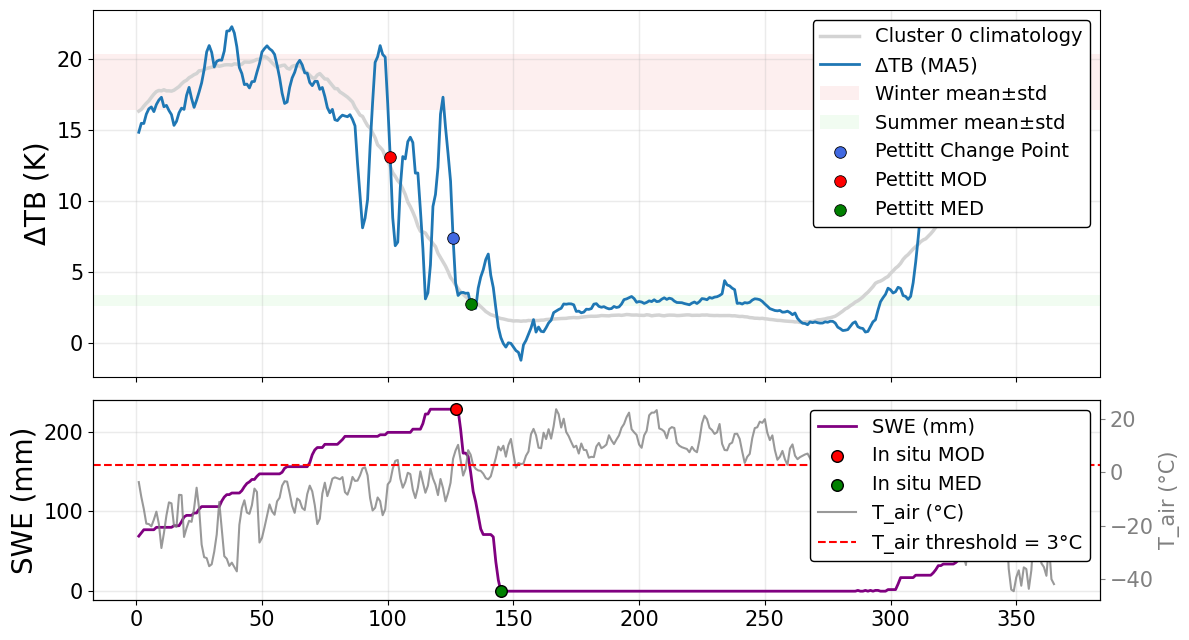

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/cluster1_rep_pixel_1994_lat66.88_lon65.62.png


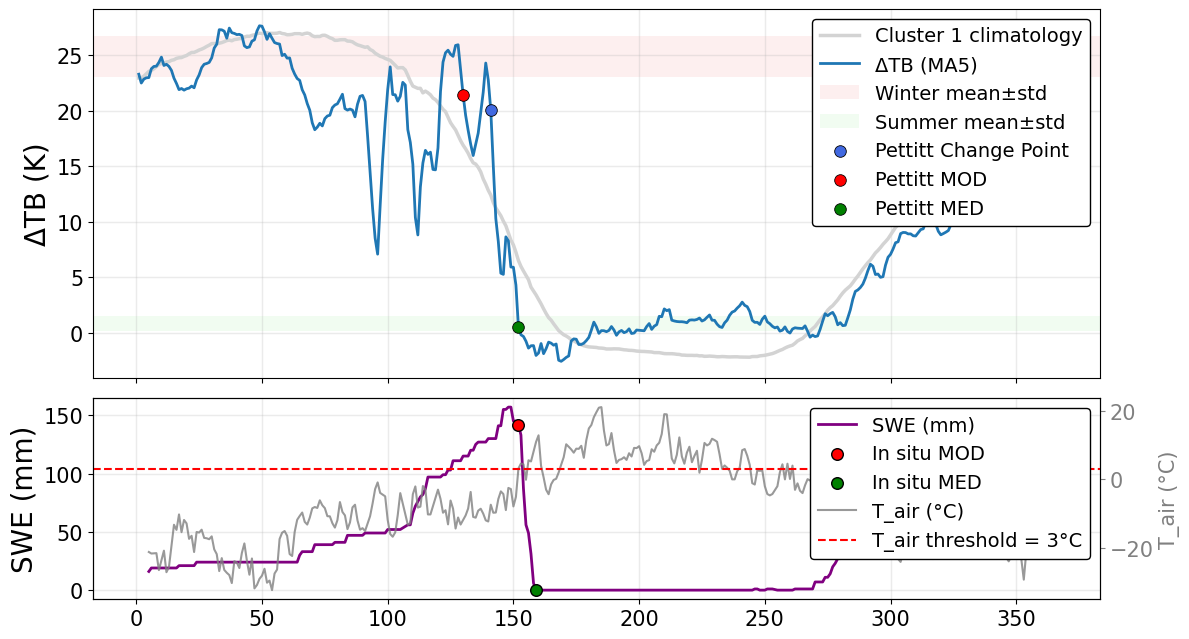

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/cluster2_rep_pixel_2014_lat63.38_lon143.12.png


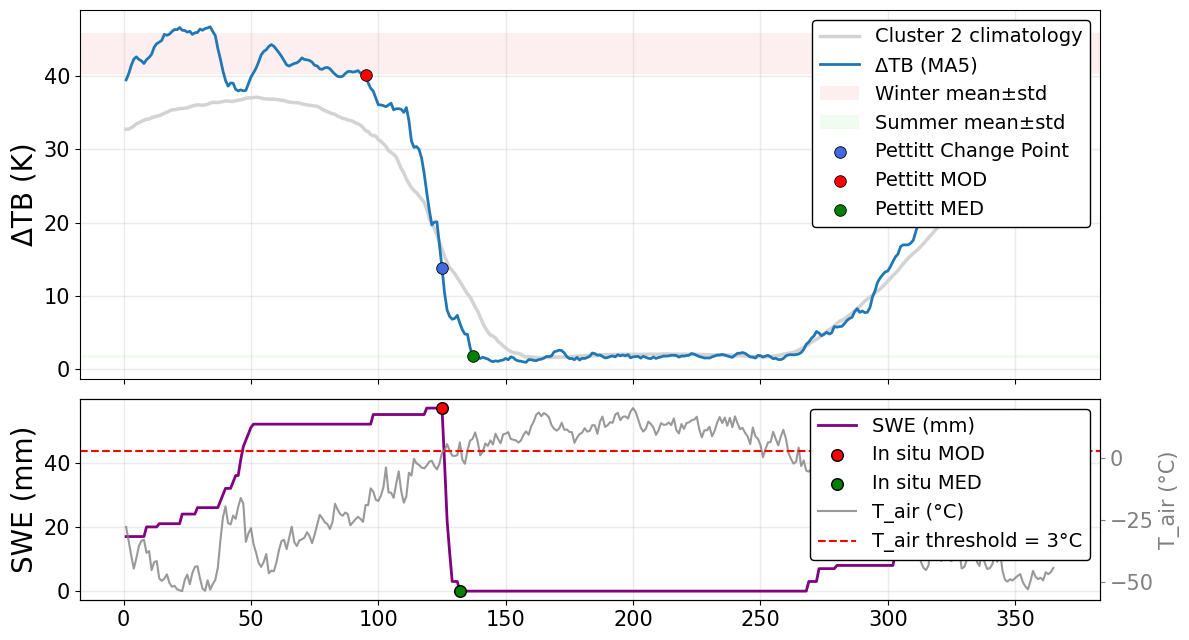

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/cluster3_rep_pixel_2003_lat66.12_lon-65.62.png


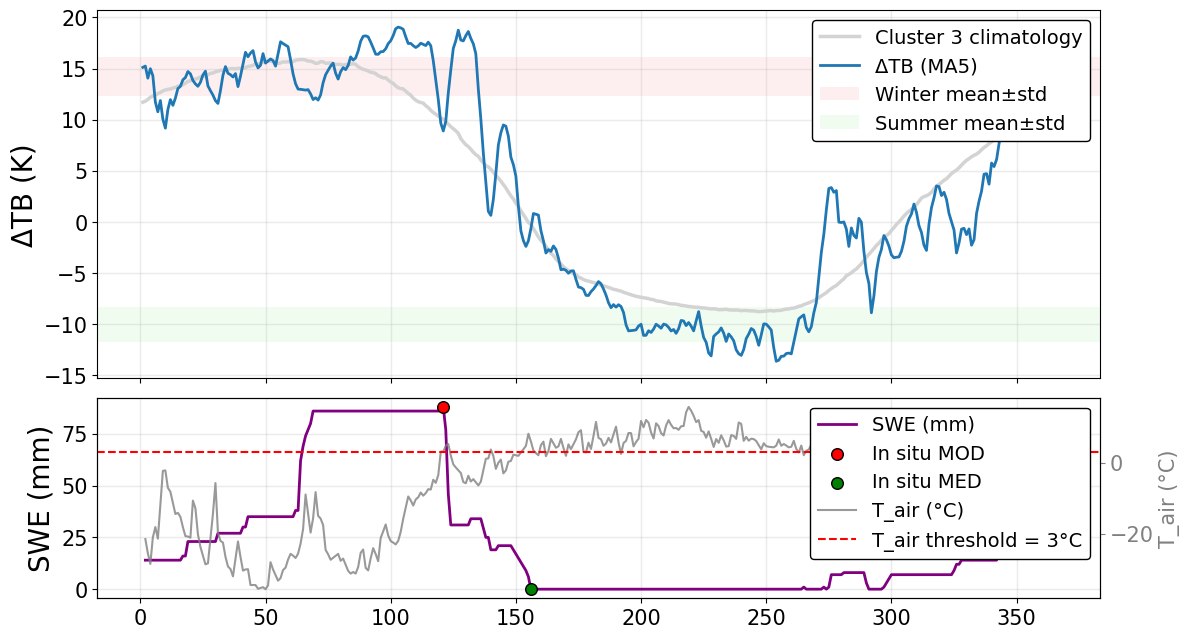

In [7]:
def insitu_csv_path(year):
    return f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Insitu/GSOD_overlap/NH_SWE_GSOD_overlap_{year}.csv"

cluster_ids = tuple(sorted(np.unique(TB_cluster[np.isfinite(TB_cluster)]).astype(int)))
cluster_ids = tuple([c for c in cluster_ids if c >= 0])

# Representative pixel: only pixels with in situ MOD
rep_raw = pick_rep_pixel_raw_rmse_insitu_only(
    tb_clim=tb_clim,
    TB_cluster=TB_cluster,
    Insitu_MOD=Insitu_MOD,
    lat_vals=lat_vals,
    lon_vals=lon_vals,
    cluster_ids=cluster_ids,
    min_insitu_years=1
)

csv_cache = {}

for cid, info in rep_raw.items():
    if info is None:
        continue

    i, j = info["i"], info["j"]

    # 1) Select year with minimum RMSE (only consider years with in situ)
    year = choose_year_by_min_rmse(
        i, j, cid,
        tb_diff, tb_clim, TB_cluster,
        Insitu_MOD,
        start_year=1988,
        end_year_tb=2022,
    )

    if year is None:
        print(f"[cluster {cid}] year selection failed (no valid in-situ years / overlap)")
        continue

    # 2) Get tb_block for the year
    tb_block = None
    for yy, block in iterate_tb_diff_by_year(1988, 2022, tb_diff):
        if yy == year:
            tb_block = block
            break

    if tb_block is None:
        print(f"[cluster {cid}] tb_block not found for year={year}")
        continue

    # 3) Load in-situ CSV (SWE (mm))
    if year not in csv_cache:
        csv_cache[year] = pd.read_csv(insitu_csv_path(year))
    df_year = csv_cache[year]

    # 4) Plot TB + SWE together
    plot_tb_with_swe(
        cid=cid, year=year, i=i, j=j,
        tb_block=tb_block,
        tb_clim=tb_clim, TB_cluster=TB_cluster,
        Pettitt_Tau=Pettitt_Tau, Pettitt_MOD=Pettitt_MOD, Pettitt_MED=Pettitt_MED,
        Insitu_csv_df_year=df_year,
        lat_vals=lat_vals, lon_vals=lon_vals,
        show_cluster_clim=True,   
    )
